<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

In [1]:
import pandas as pd
import numpy as np

from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(palette='summer')

Выгрузим два датасета и посмотрим на них

In [2]:
data_eng = pd.read_csv('/content/data_problems_translated.csv', index_col='Unnamed: 0')
data_eng.head()

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms
3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,"Dima, who came from Vrunlandia, said that ther...",graphs


In [3]:
data_eng.shape

(5273, 2)

In [4]:
indices = np.random.choice(data_eng.shape[0], 5)

for idx in indices:
    print(data_eng['problem_text'][idx], '\t', data_eng['topic'][idx], '\n')

On the board, the numbers 1, 2, 3,..., 1000. Two times the number is erased. The game ends when there are two numbers left on the board. If the sum is divided by 3, then the person who made the first move, if not his partner, wins. Which one wins in the right game? 	 number_theory 

Let the natural number n be that n + 1 is divided by 24. Prove that the sum of all natural n dividers is divided by 24. 	 number_theory 

A natural number is allowed. It is allowed to set the number plus figures arbitrarily and calculate the sum (e.g. 123456789 can be obtained from 12345 + 6 + 789 = 13140). With the number obtained, it is again allowed to perform the transaction, and so on. Prove that from any number it is possible to obtain a single one with not more than 10 such transactions. 	 invariant 

Borya then took each card, looked at the color of the number on it, multiplied all of Anina's numbers with the same color on the other cards, and recorded the result on the back of the card (if the othe

In [5]:
data_eng['topic'].value_counts()

,count
topic,
number_theory,2396
combinatorics,1020
dirichlet,441
polynoms,426
graphs,384
geometry,371
invariant,235


In [6]:
data_eng['topic'].nunique()

7

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data_eng['topic'] = encoder.fit_transform(data_eng['topic'].values)
data_eng

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,5
1,( b) Will the statement of the previous challe...,5
2,The quadratic three-member graph with the coef...,6
3,Can you draw on the surface of Rubik's cube a ...,0
4,"Dima, who came from Vrunlandia, said that ther...",3
...,...,...
5268,Can the number n! end with the figures of 76.0...,5
5269,Find all natural m and n for which m! + 12 = n2.,5
5270,"The correct 5,000-column has a 2001 vertebrate...",1
5271,Find the maximum number N for which there are ...,5


In [8]:
data_rus = pd.read_excel('/content/data_problems.xlsx', index_col='Unnamed: 0')
data_rus.head()

,Задача,Тема
0,Между девятью планетами Солнечной системы введ...,Графы
1,"В стране Цифра есть 9 городов с названиями 1, ...",Графы
2,"В государстве 100 городов, и из каждого из них...",Графы
3,"В классе 30 человек. Может ли быть так, что 9 ...",Графы
4,В городе Маленьком 15 телефонов. Можно ли их с...,Графы


In [9]:
data_rus.shape

(5273, 2)

In [10]:
indices = np.random.choice(data_rus.shape[0], 5)
data_rus = data_rus.reset_index(drop=True)

for idx in indices:
    print(data_rus['Задача'][idx], '\t', data_rus['Тема'][idx], '\n')

а) Пусть p – простое число, отличное от 3. Докажите, что число  
1...1 (p единиц) не делится на p.  	 Теория чисел 

Последовательность {an} строится следующим образом:  a1 = p  – простое число, имеющее ровно 300 ненулевых цифр, an+1 – период десятичной дроби
1/an, умноженный на 2. Найдите число a2003.  	 Теория чисел 

В стране лингвистов существует n языков. Там живет m людей, каждый из которых знает ровно три языка, причём для разных людей эти наборы различны. Известно, что максимальное число людей, любые два из которых могут поговорить без посредников, равно k. Оказалось, что  11n ≤ k ≤ m/2.
Докажите, что тогда в стране найдутся хотя бы mn пар людей, которые не смогут поговорить без посредников.  	 Графы 

Дан отрезок OA. Из конца отрезка A выходит 5 отрезков AB1, AB2, AB3, AB4, AB5. Из каждой точки Bi могут выходить ещё пять новых отрезков или ни одного нового отрезка и т.д. Может ли число свободных концов построенных отрезков равняться 1001? Под свободным концом отрезка понимаем 

In [11]:
data_rus['Тема'].value_counts()

,count
Тема,
Теория чисел,2396
Комбинаторика,1020
Дирихле,441
Многочлен,426
Графы,384
Геометрия,371
Инвариант,235


In [12]:
data_rus['Тема'].nunique()

7

In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data_rus['Тема'] = encoder.fit_transform(data_rus['Тема'].values)
data_rus

,Задача,Тема
0,Между девятью планетами Солнечной системы введ...,1
1,"В стране Цифра есть 9 городов с названиями 1, ...",1
2,"В государстве 100 городов, и из каждого из них...",1
3,"В классе 30 человек. Может ли быть так, что 9 ...",1
4,В городе Маленьком 15 телефонов. Можно ли их с...,1
...,...,...
5268,Дьявол предлагает Человеку сыграть в следующую...,2
5269,По шоссе в одном направлении едут 10 автомобил...,2
5270,В пространстве имеются 30 ненулевых векторов. ...,2
5271,На плоскости даны две точки A и B. Пусть C – н...,2


На вид датасеты индентичные, просто один является переводом другого.  
Выше мы закодировали таргеты, теперь займемся подготовкой моделей

Зададим токенизаторы для наших моделей, а также класс Dataset для работы с даннми через pytorch

In [14]:
import transformers
tokenizer_rubert = transformers.AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
tokenizer_mathbert = transformers.BertTokenizer.from_pretrained('tbs17/MathBERT')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [15]:
class Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], max_length=self.max_length,
                                  truncation=True, padding='max_length',
                                  return_tensors='pt')

        return {'input_ids': encoding['input_ids'].squeeze(0),
                'attention_mask': encoding['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[idx])}

In [16]:
dataset_rus = Dataset(texts=data_rus['Задача'].tolist(),
                        labels=data_rus['Тема'].tolist(),
                        tokenizer=tokenizer_rubert)


dataloader_rus = DataLoader(dataset_rus, batch_size=16, shuffle=True)

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

Напишем класс по условию

In [17]:
from typing import Union, List

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module],
                 num_classes=7, dropout=0.2):
        super().__init__()
        self.backbone = transformers.AutoModel.from_pretrained(base_transformer_model, output_attentions=True)

        hidden_size = self.backbone.config.hidden_size
        self.linear = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs, attention_mask):
        outputs = self.backbone(input_ids=inputs, attention_mask=attention_mask)

        outputs = self.linear(self.dropout(outputs.last_hidden_state[:, 0, :]))

        return outputs

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [18]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

Зададим модель и функцию ошибки, а затем напишем тренировочный цикл

In [20]:
model_rubert = "cointegrated/rubert-tiny2"
criterion = nn.CrossEntropyLoss()

In [21]:
import copy

def train_transformer(transformer_model, dataloader, freeze_backbone=True, num_epochs=5,
                      criterion=criterion):
    losses = []
    model = copy.copy(transformer_model)
    model.to(device)

    if freeze_backbone:
        freeze_backbone_function(model)

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()))

    for epoch in range(num_epochs):
        epoch_losses = []
        model.train()

        for batch in tqdm(dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))

    return losses, model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [22]:
rubert_tiny_transformer_model = TransformerClassificationModel(base_transformer_model=model_rubert)
losses_freezed, rubert_tiny_finetuned_with_freezed_backbone = train_transformer(rubert_tiny_transformer_model, dataloader_rus,
                                                                                freeze_backbone=True, num_epochs=20)

rubert_tiny_transformer_model = TransformerClassificationModel(base_transformer_model=model_rubert)
losses, rubert_tiny_full_finetuned = train_transformer(rubert_tiny_transformer_model, dataloader_rus,
                                                       freeze_backbone=False, num_epochs=20)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training epoch 0::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/330 [00:00<?, ?it/s]

...

Training epoch 15::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 16::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 17::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 18::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 19::   0%|          | 0/330 [00:00<?, ?it/s]

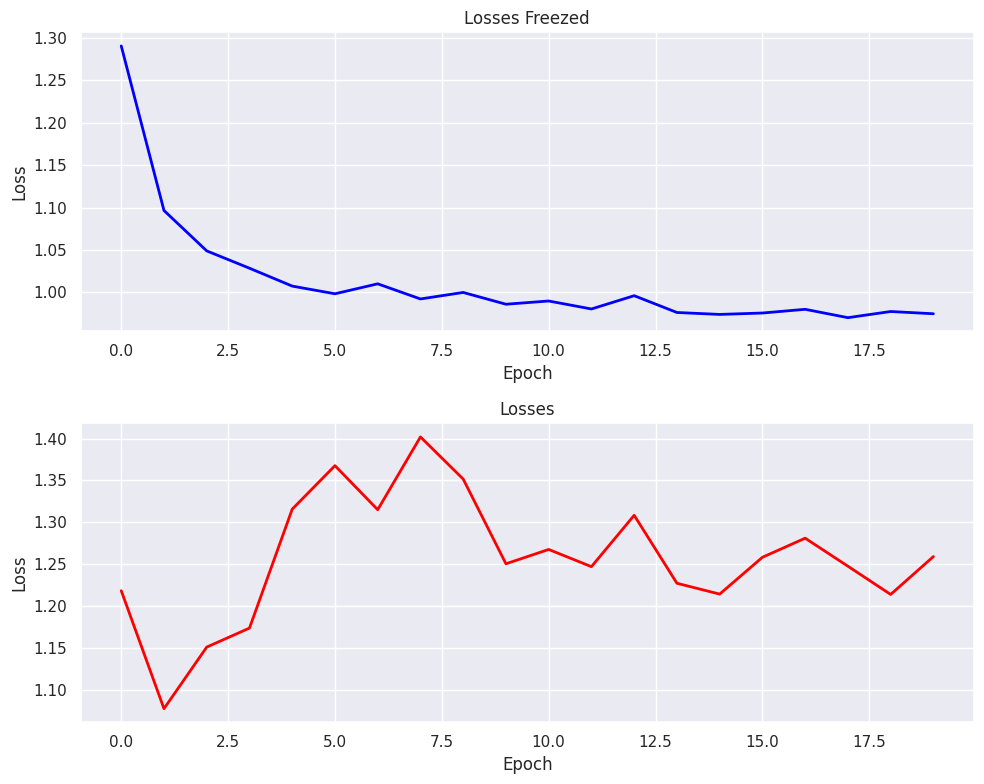

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(np.arange(len(losses_freezed)), losses_freezed, 'b-', linewidth=2)
ax1.set_title('Losses Freezed', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(np.arange(len(losses)), losses, 'r-', linewidth=2)
ax2.set_title('Losses', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [24]:
print(f' Минимальная ошибка с замороженными весами: {min(losses_freezed):.3f}; \n Без замораживания: {min(losses):.3f}')

 Минимальная ошибка с замороженными весами: 0.970; 
 Без замораживания: 1.077


Можем видеть, что модели действительно обучаются. Модель без замораживания оказалась хуже и менее стабильной.


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

Проделаем то же самое с моделью MathBert, создав для нее свой Dataset

In [25]:
dataset_eng = Dataset(texts=data_eng['problem_text'].tolist(),
                        labels=data_eng['topic'].tolist(),
                        tokenizer=tokenizer_mathbert)


dataloader_eng = DataLoader(dataset_eng, batch_size=16, shuffle=True)

In [26]:
model_mathbert = 'tbs17/MathBERT'

In [28]:
mathbert_transformer_model = TransformerClassificationModel(base_transformer_model=model_mathbert)
losses_freezed, mathbert_finetuned_with_freezed_backbone = train_transformer(mathbert_transformer_model, dataloader_eng,
                                                                             freeze_backbone=True, num_epochs=10)

mathbert_transformer_model = TransformerClassificationModel(base_transformer_model=model_mathbert)
losses, mathbert_full_finetuned = train_transformer(mathbert_transformer_model, dataloader_eng,
                                                    freeze_backbone=False, num_epochs=10)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training epoch 0::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/330 [00:00<?, ?it/s]

...

Training epoch 5::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/330 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/330 [00:00<?, ?it/s]

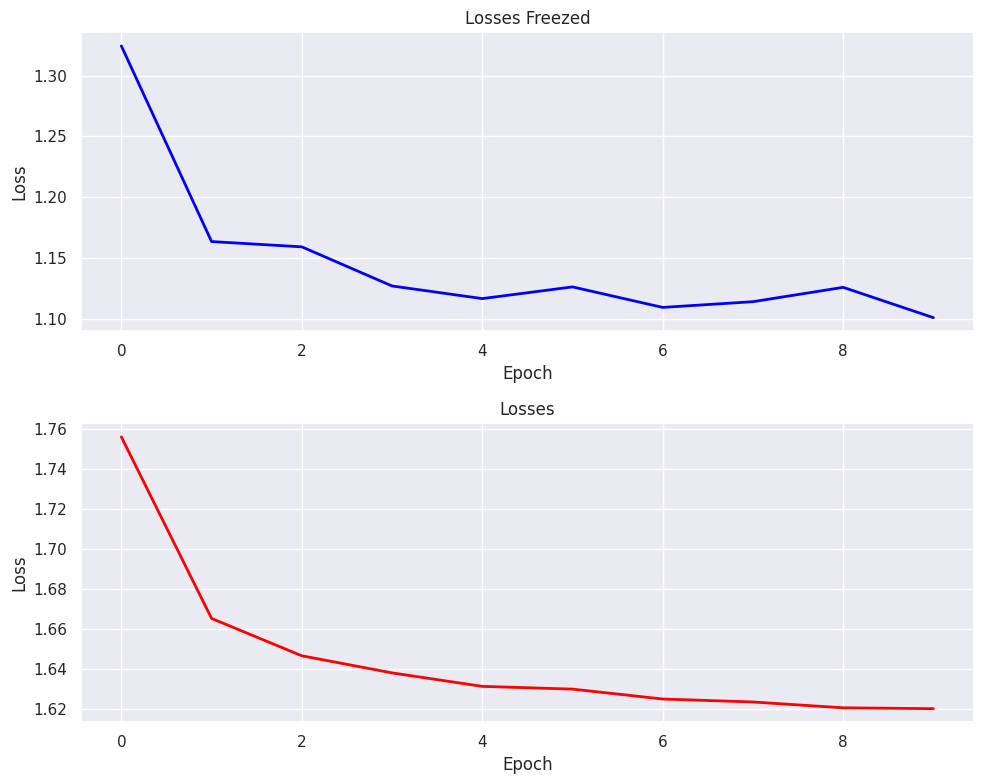

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(np.arange(len(losses_freezed)), losses_freezed, 'b-', linewidth=2)
ax1.set_title('Losses Freezed', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(np.arange(len(losses)), losses, 'r-', linewidth=2)
ax2.set_title('Losses', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [30]:
print(f'Минимальная ошибка с замороженными весами: {min(losses_freezed):.3f}; \nБез замораживания: {min(losses):.3f}')

Минимальная ошибка с замороженными весами: 1.101; 
Без замораживания: 1.620


В этом случае также модель без замораживания показала меньший лосс на тренировочной выборке.

В целом, модели rubert оказались лучше, чем mathbert.  
  
Возможно, это связано с тем, что датасет изначально был на русском, и перевод данных на английский оказался не очень качественным

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [31]:
def draw_first_layer_attention_maps(attention_head_ids, text, model, tokenizer):

    model.eval()

    for idx, example in enumerate(text):
        example = [example]
        inputs = tokenizer(example, return_tensors='pt', truncation=True, max_length=128)

        with torch.no_grad():
            outputs = model.backbone(input_ids=inputs['input_ids'],
                                     attention_mask=inputs['attention_mask'],
                                     output_attentions=True)

        attn = outputs.attentions[0][0]
        tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

        fig, axes = plt.subplots(2, 2, figsize=(16, 14))
        axes = axes.flatten()

        for i, head_id in enumerate(attention_head_ids[:4]):
            im = axes[i].imshow(attn[head_id].numpy(), cmap='viridis')
            axes[i].set_title(f'Head {head_id}', fontsize=14)
            axes[i].set_xlabel('Key Tokens', fontsize=12)
            axes[i].set_ylabel('Query Tokens', fontsize=12)

            axes[i].set_xticks(range(len(tokens)))
            axes[i].set_yticks(range(len(tokens)))
            axes[i].set_xticklabels(tokens, rotation=90, fontsize=10)
            axes[i].set_yticklabels(tokens, fontsize=10)

            plt.colorbar(im, ax=axes[i])

        for j in range(len(attention_head_ids[:4]), 4):
            axes[j].axis('off')

        plt.suptitle(f'Example {idx+1} - Attention Maps (First Layer)\nText: {example[:100]}...', fontsize=14)
        plt.tight_layout()
        plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


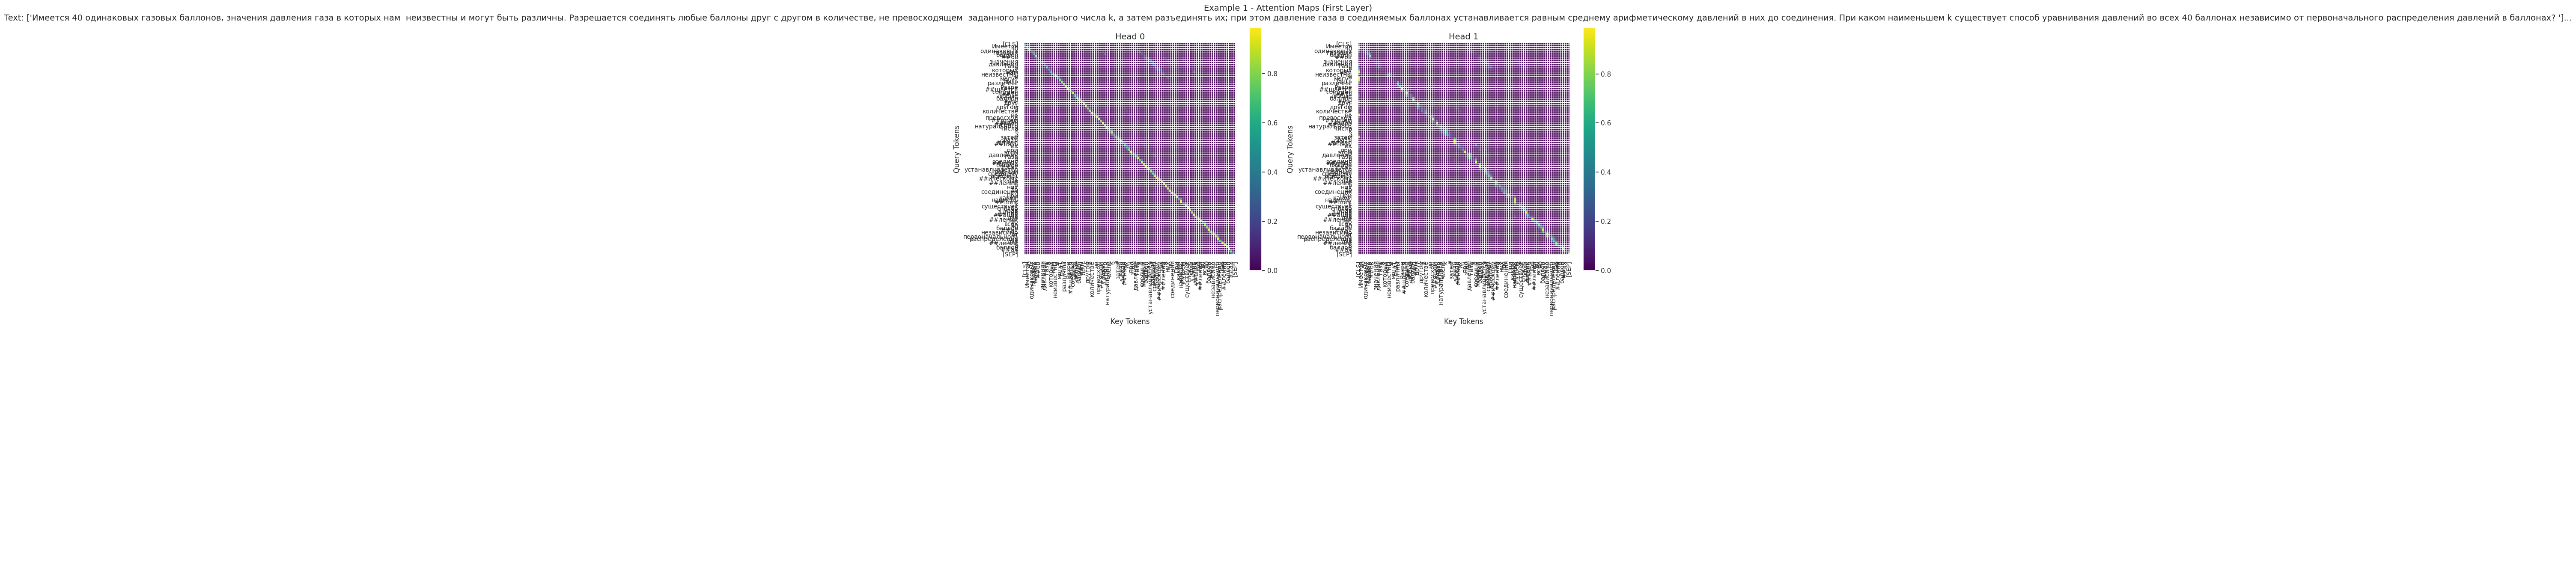

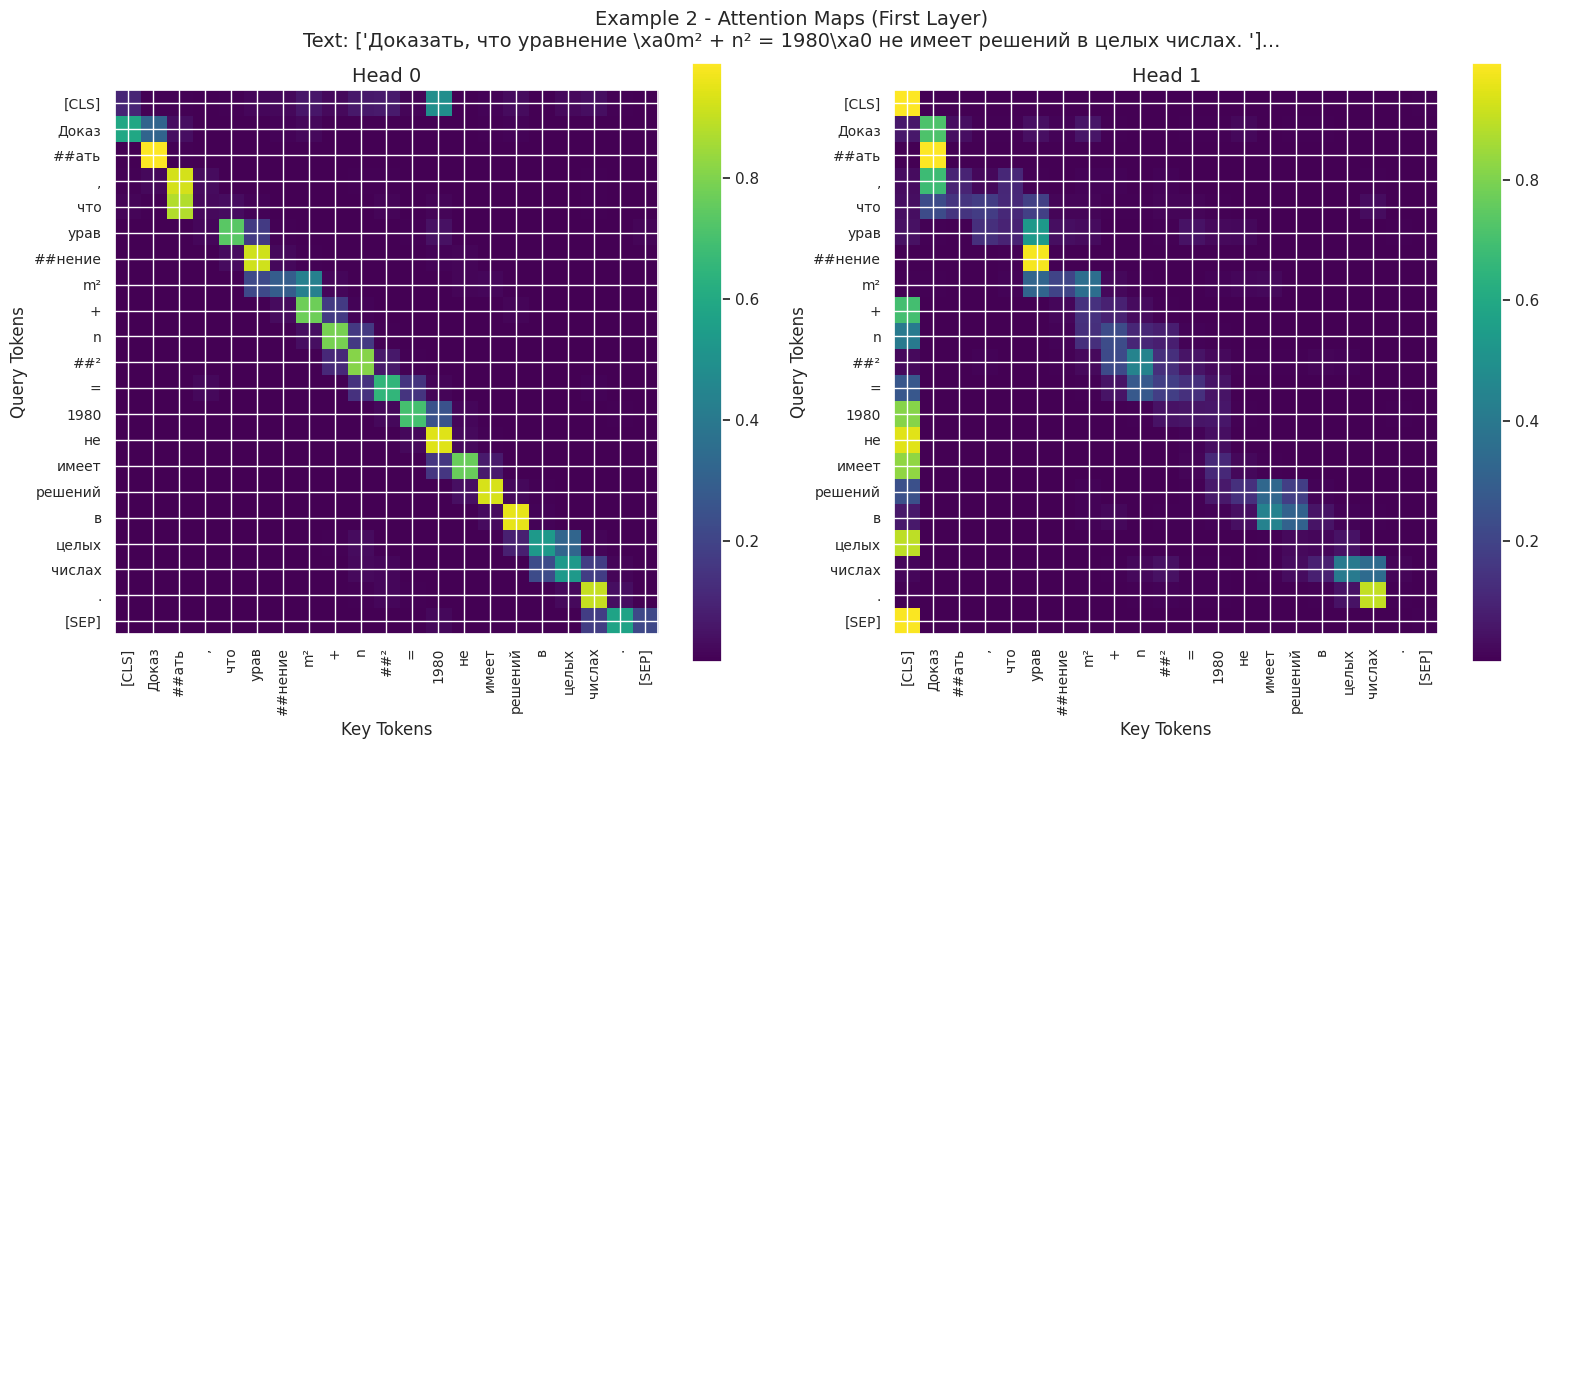

In [36]:
draw_first_layer_attention_maps(attention_head_ids=[0, 1], text=data_rus['Задача'].sample(2),
                                model=TransformerClassificationModel(base_transformer_model=model_rubert).to('cpu'), tokenizer=tokenizer_rubert)

**Первый пример:**  
В первой голове связи в основном лежат на диагонали, то есть эта голова показывает связь следующего слова с предыдущим.
Вторая голова похожа на первую, но также улавливает связи всех токенов с токеном начала текста.   
  
**Второй пример:**  
Похож на первый, головы выглядят структурно очень схожими


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


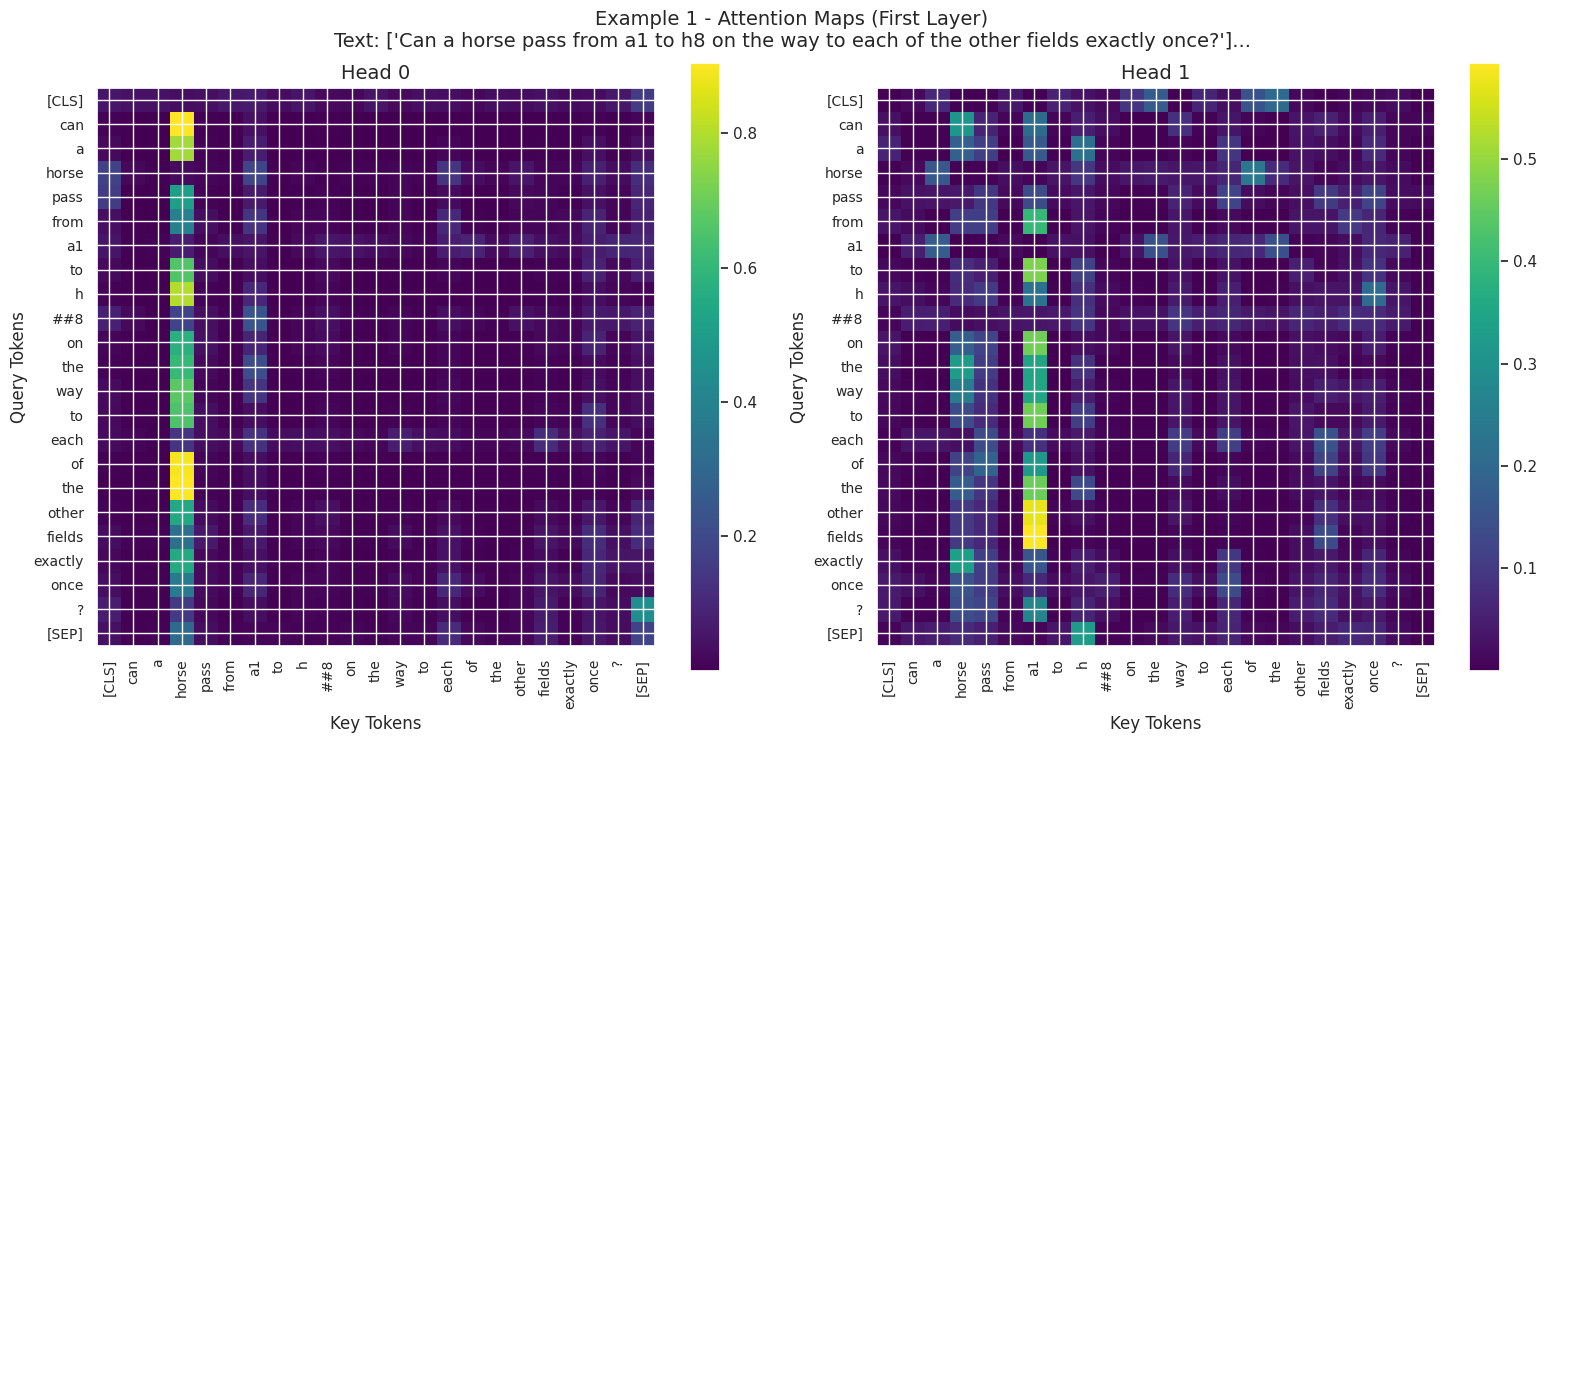

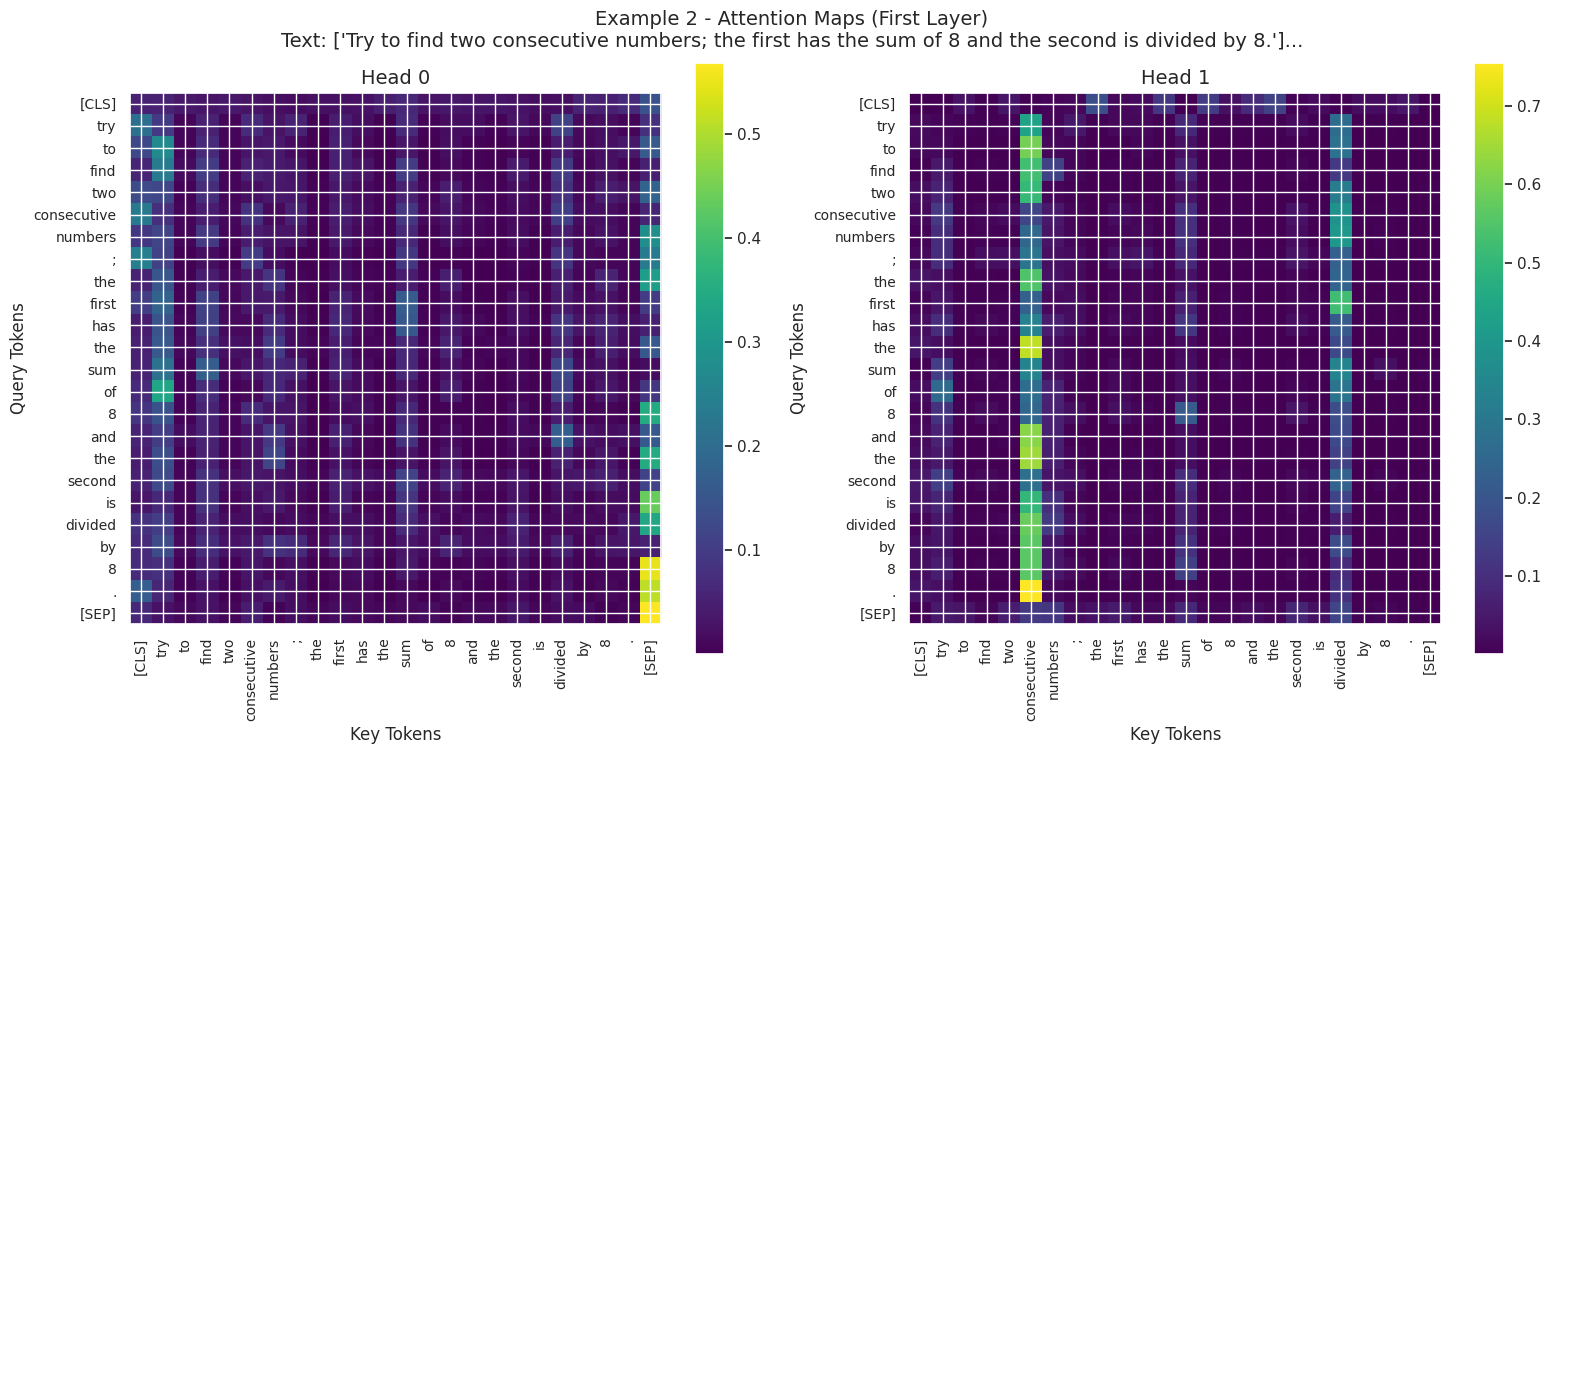

In [37]:
draw_first_layer_attention_maps(attention_head_ids=[0, 1], text=data_eng['problem_text'].sample(2),
                                model=TransformerClassificationModel(base_transformer_model=model_mathbert).to('cpu'), tokenizer=tokenizer_mathbert)

В этом случае во всех примерах выделяются вертикальные линии

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

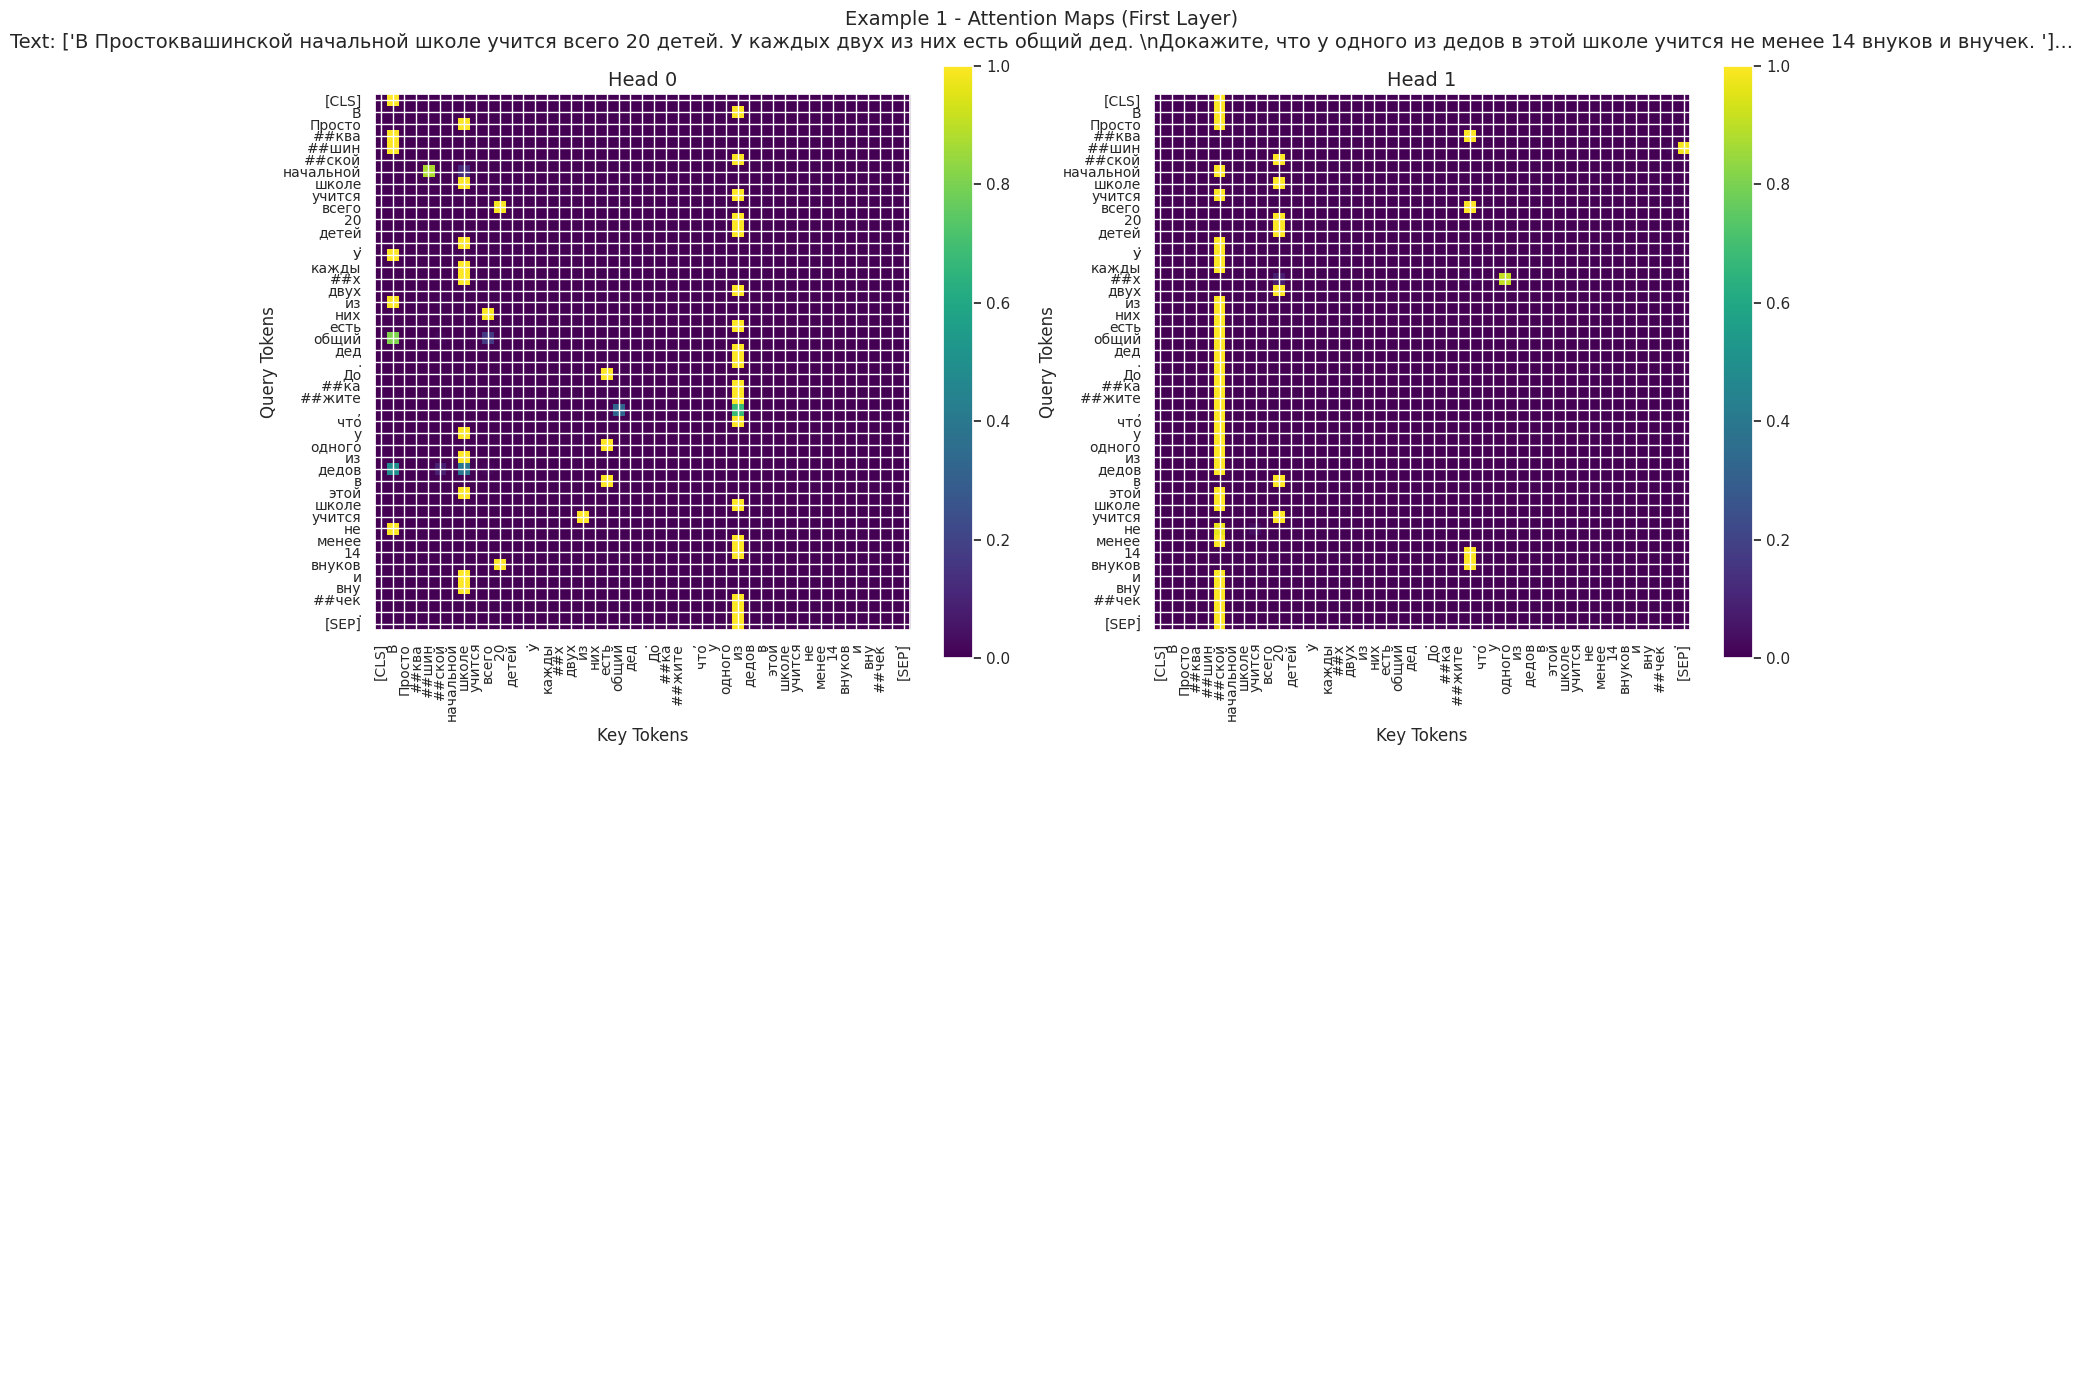

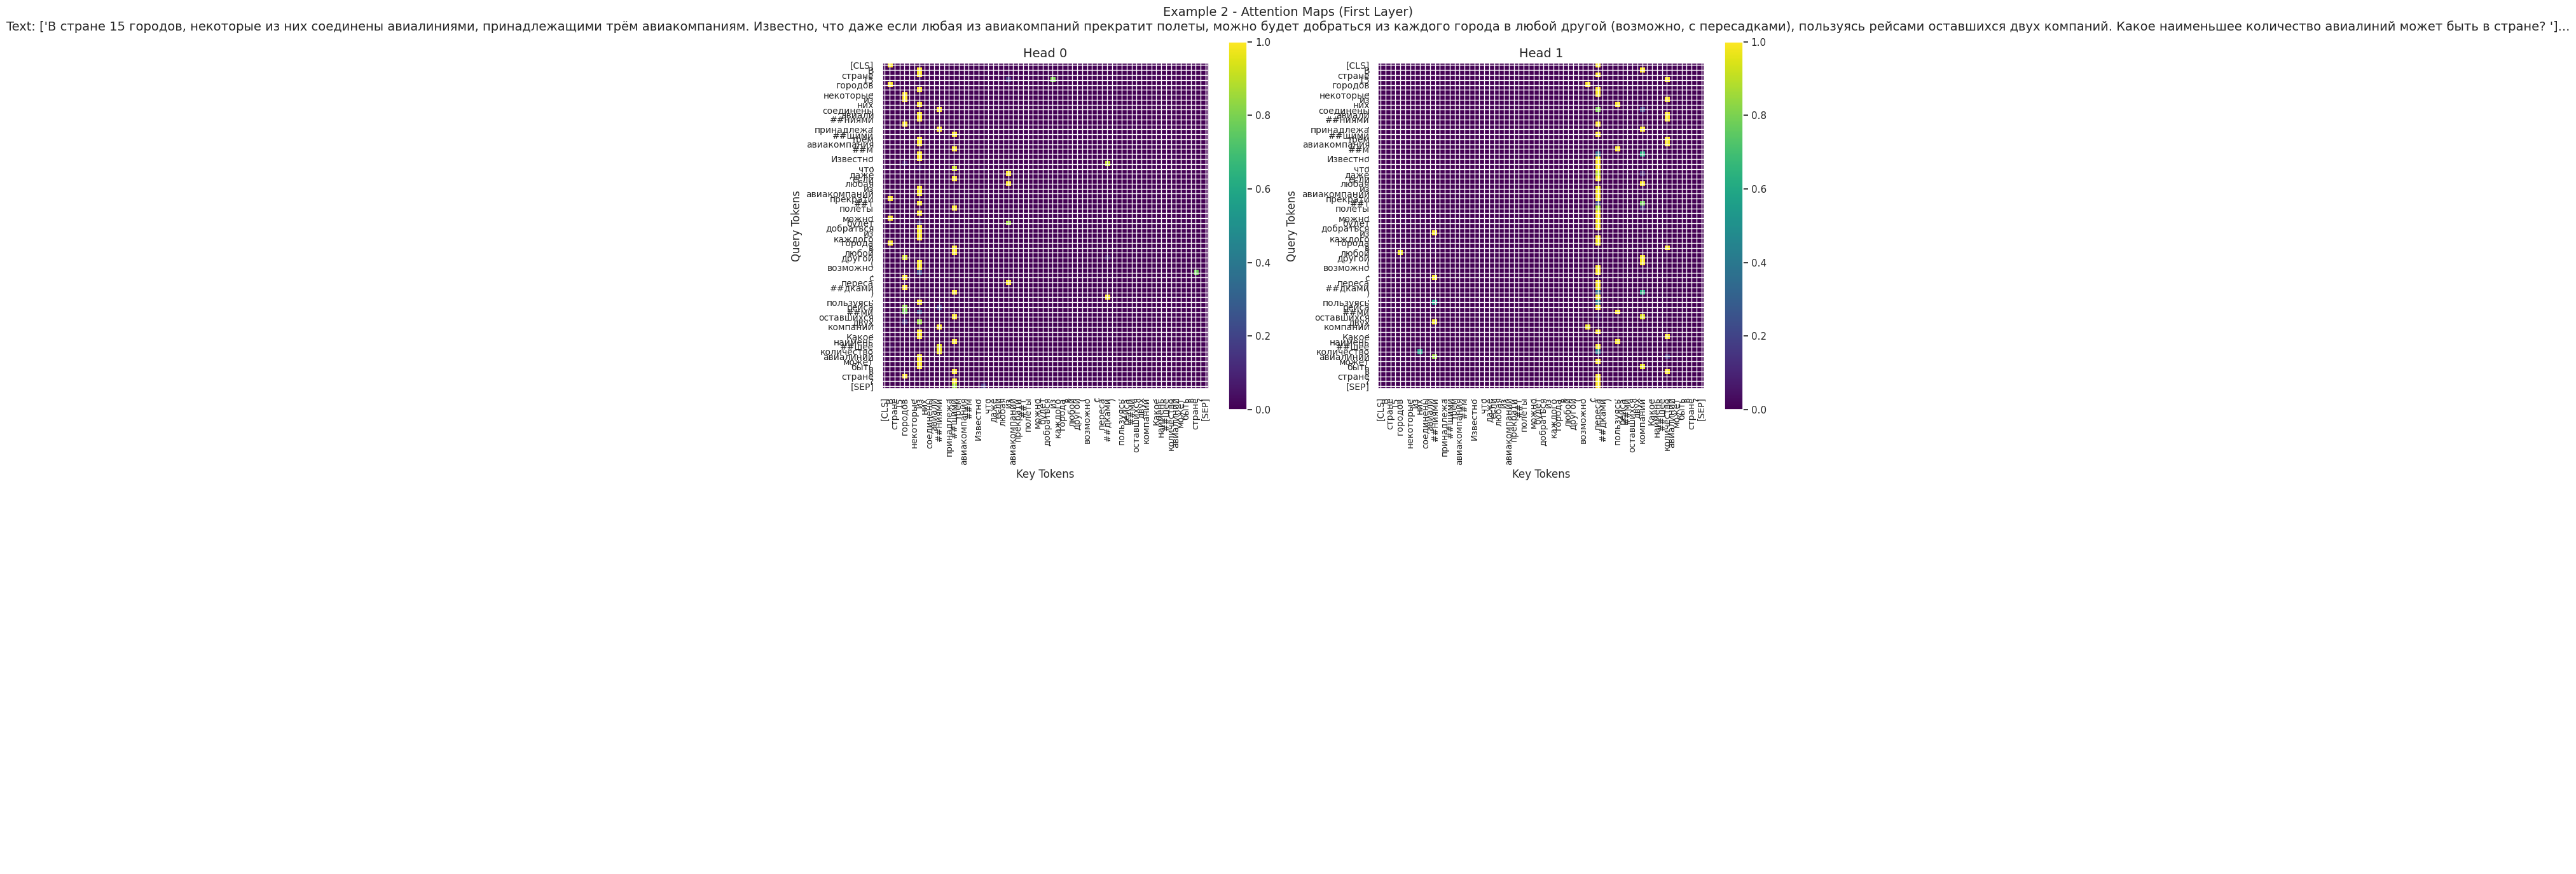

In [38]:
draw_first_layer_attention_maps(attention_head_ids=[0, 1], text=data_rus['Задача'].sample(2),
                                model=rubert_tiny_full_finetuned.to('cpu'), tokenizer=tokenizer_rubert)

**Первый пример:**  
В головах очень ярко выделены по одной диагонали, а также некоторые другие "случайные" пары токенов  
**Второй пример:**  
Аналогично

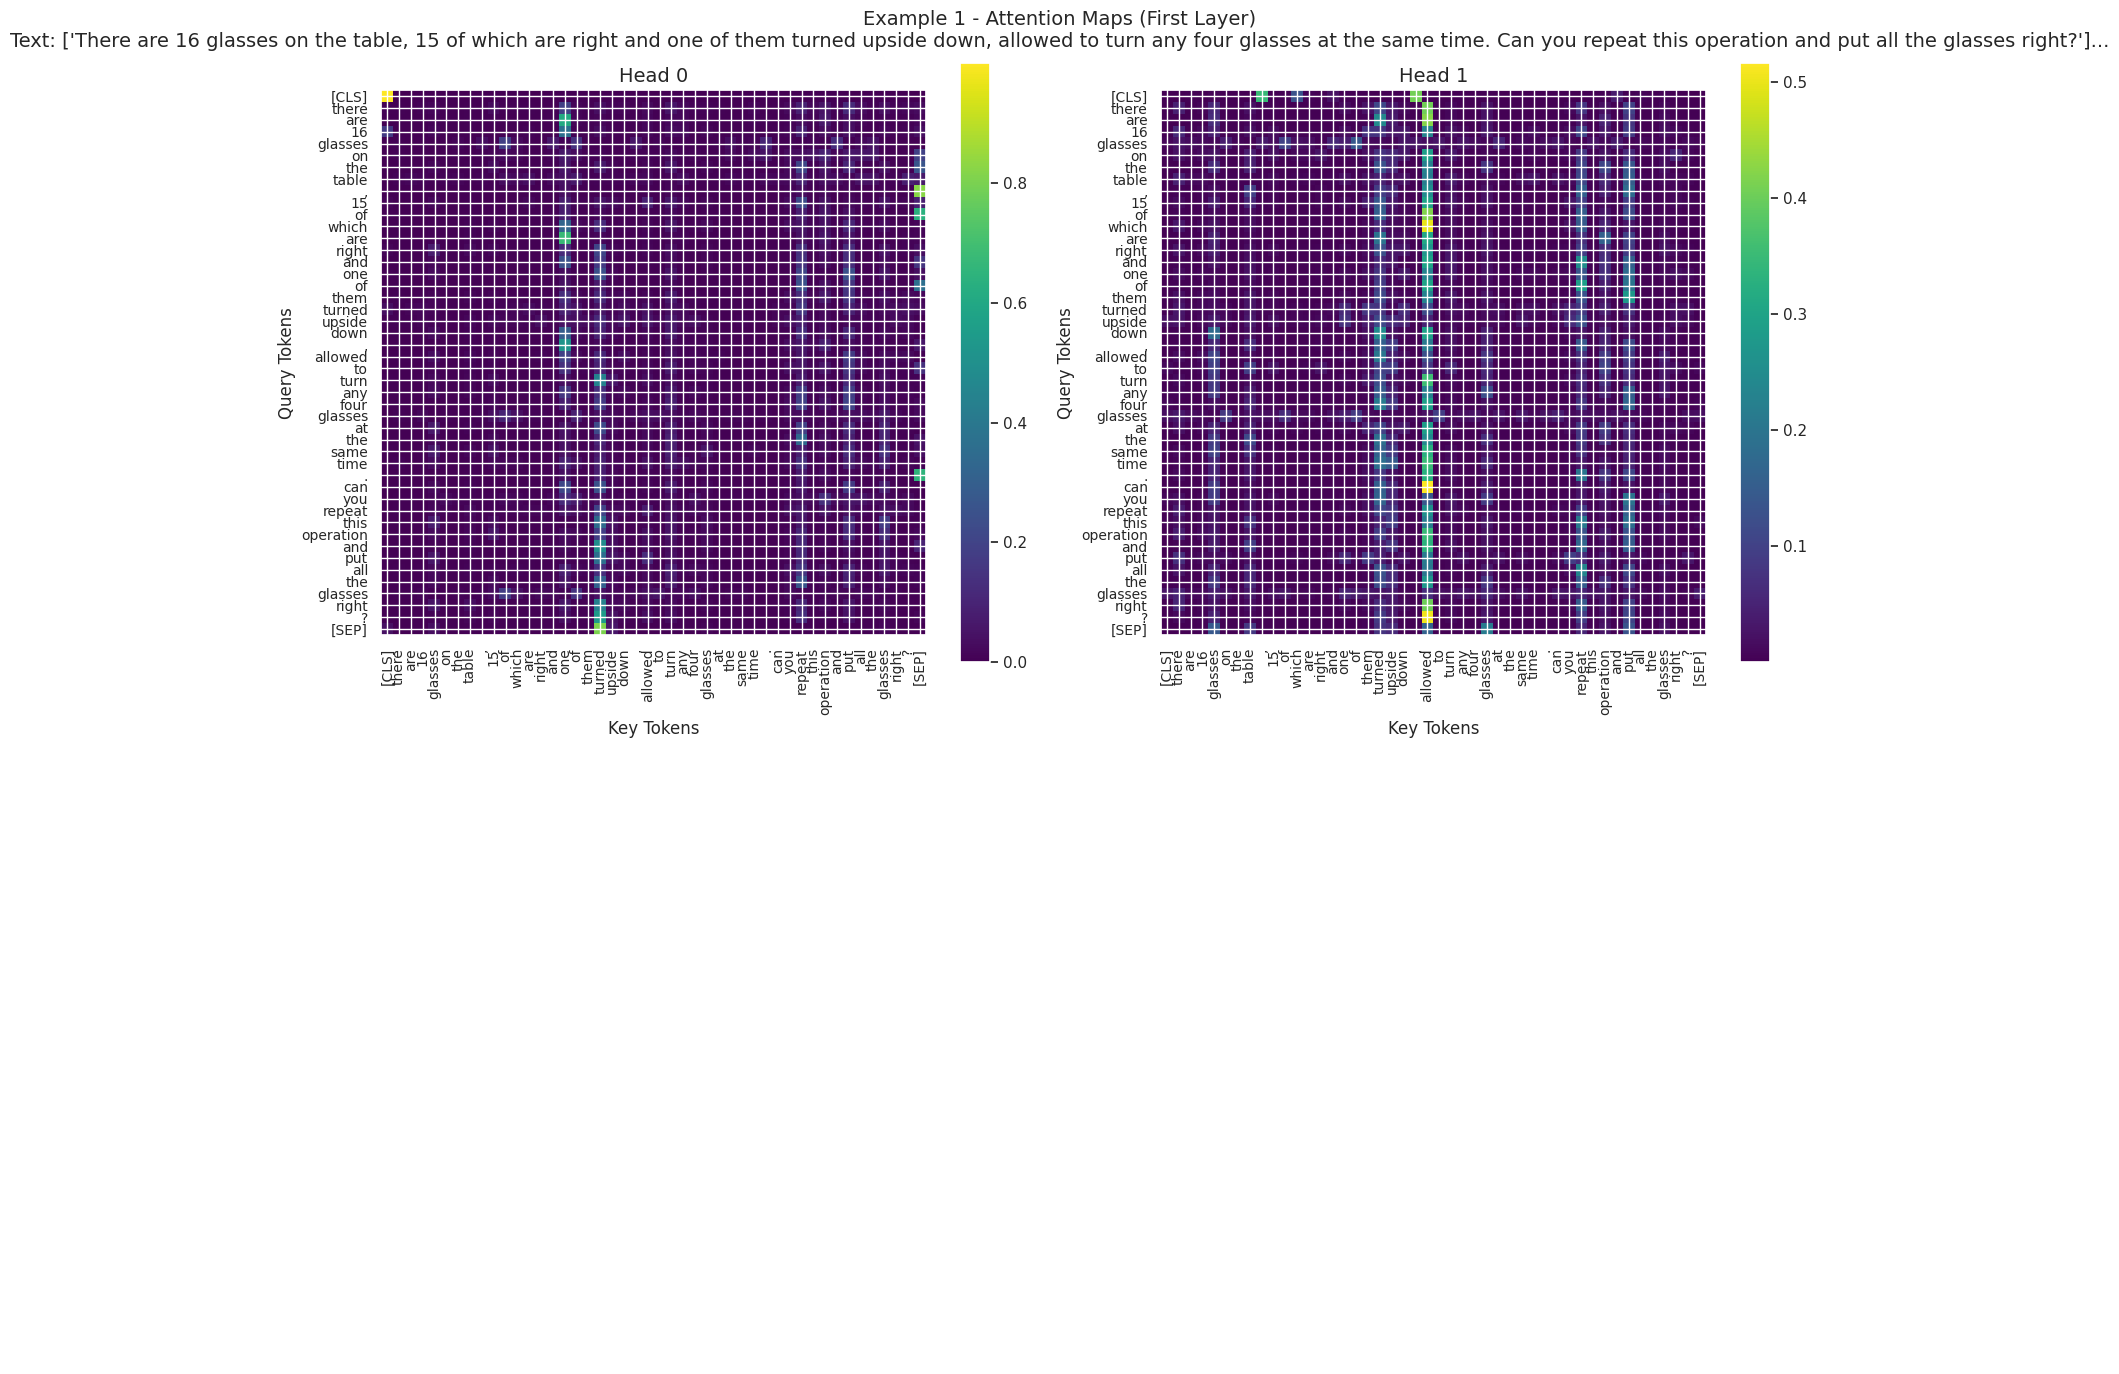

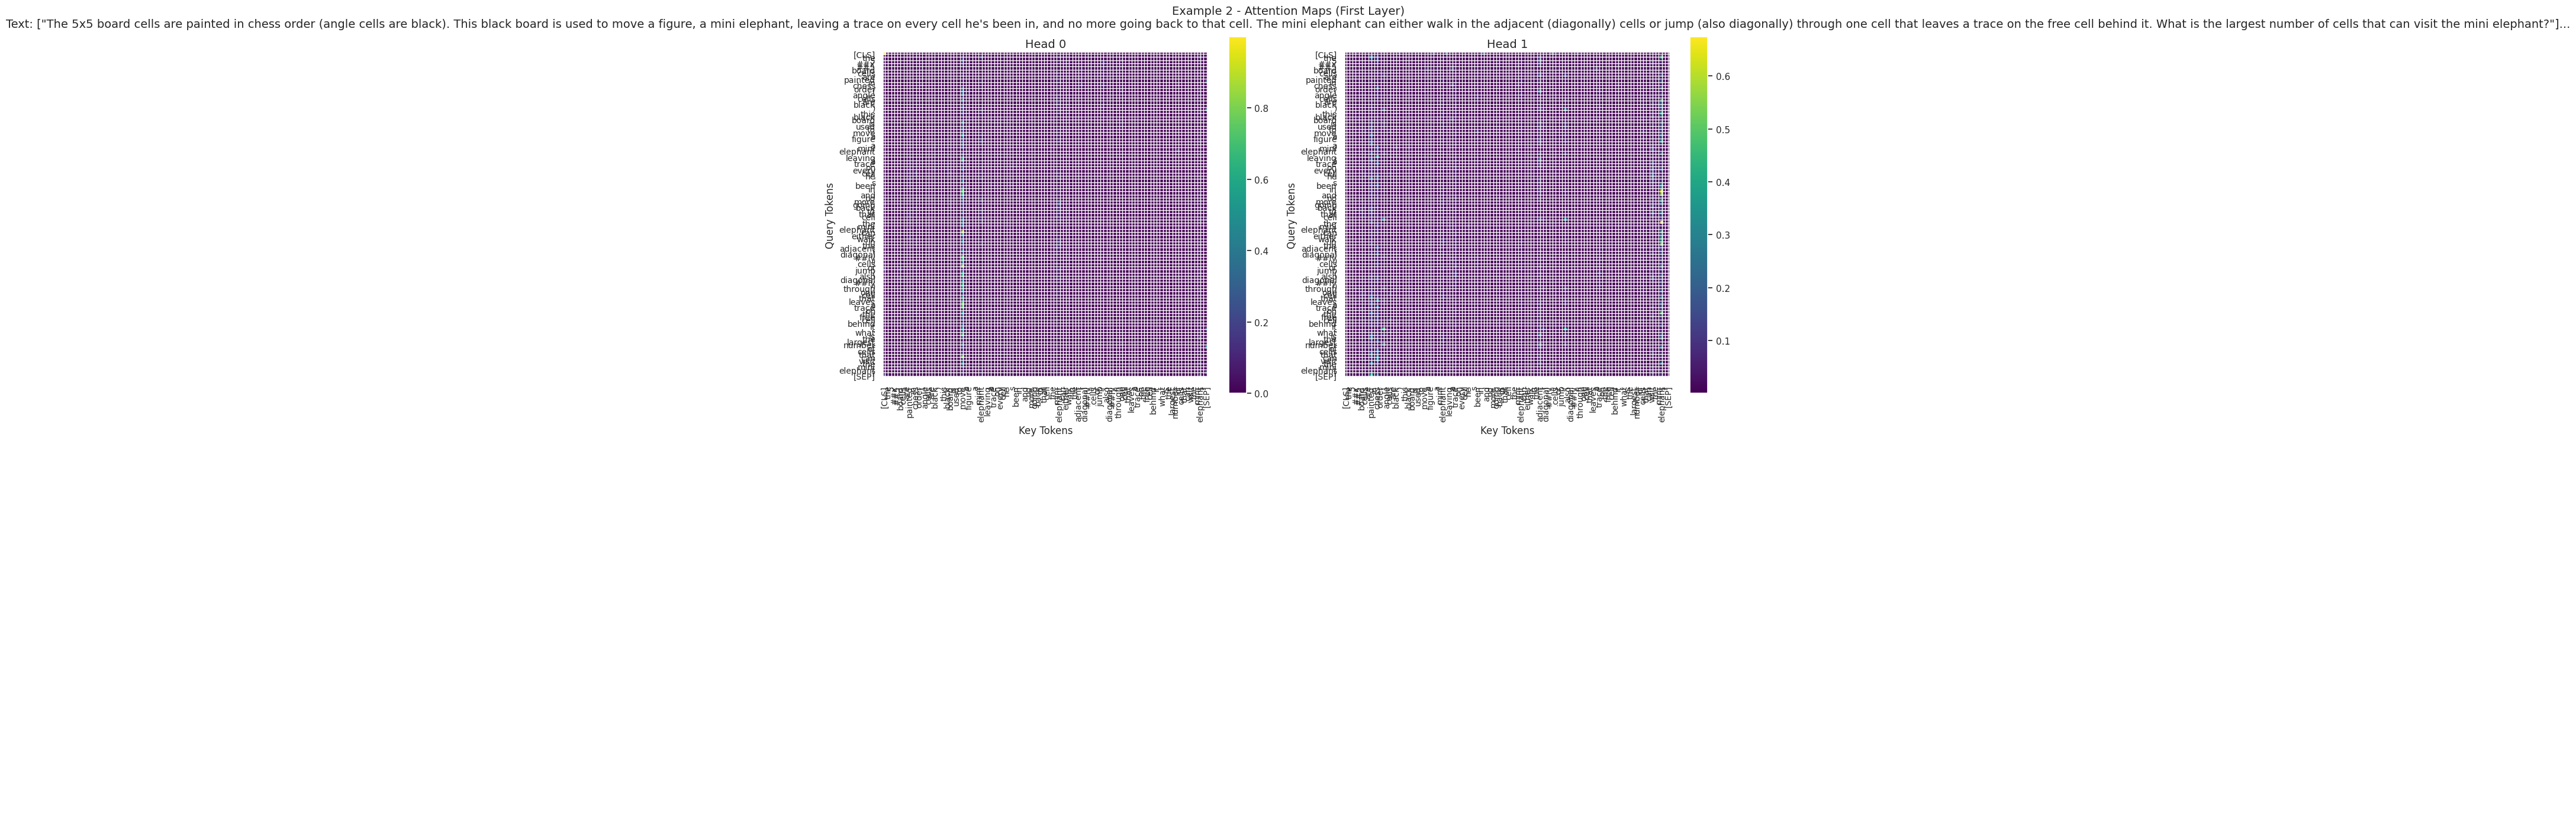

In [39]:
draw_first_layer_attention_maps(attention_head_ids=[0, 1], text=data_eng['problem_text'].sample(2),
                                model=mathbert_full_finetuned.to('cpu'), tokenizer=tokenizer_mathbert)

В этом случае активации как будто равномерные и не структурированные